In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import LSTM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/news_dataset.csv")
df.head(5)

,x,y
0,WATCH: Trump Just Told All The Anti-Gay Bigots...,0
1,"China backs U.N. call for justice in Yemen, U....",1
2,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,0
3,Lawmakers aim to delay U.S. ceding control of ...,1
4,"Trump STRANDED, In Full Panic As ANOTHER Perfo...",0


In [ ]:
x =df["x"]
y = df["y"]

In [ ]:
vocab = 20000
max_len=300
token = Tokenizer(num_words=vocab ,oov_token="<OOV>")
token.fit_on_texts(x)

In [ ]:
x = token.texts_to_sequences(x)

In [ ]:
x = pad_sequences(x , maxlen=max_len, padding="post", truncating="post")

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab, output_dim=128 , input_length=max_len),
    tf.keras.layers.Bidirectional(LSTM(64 , return_sequences=False)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=32 , activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(units=1 , activation="sigmoid"),
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer="adam" , loss=tf.losses.BinaryCrossentropy() , metrics=["accuracy"] )

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,662,977 (10.16 MB)

 Trainable params: 2,662,977 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early = tf.keras.callbacks.EarlyStopping(patience=15 , restore_best_weights=True)

In [ ]:
from sklearn.model_selection import train_test_split as tts
X_train , X_test  , Y_train , Y_test = tts(x ,y, test_size=0.2)

In [ ]:
X_train.shape , X_test.shape  , Y_train.shape , Y_test.shape

((4663, 300), (1166, 300), (4663,), (1166,))

In [ ]:
early = tf.keras.callbacks.EarlyStopping(patience=3 , verbose=1,restore_best_weights=True)

In [ ]:
his = model.fit(X_train , Y_train, epochs=5 , validation_data=(X_test , Y_test), callbacks=[early])

Epoch 1/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 74s 479ms/step - accuracy: 0.9983 - loss: 0.0153 - val_accuracy: 0.9949 - val_loss: 0.0297
Epoch 2/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 62s 422ms/step - accuracy: 0.9998 - loss: 0.0026 - val_accuracy: 0.9966 - val_loss: 0.0204
Epoch 3/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 64s 434ms/step - accuracy: 1.0000 - loss: 1.6790e-04 - val_accuracy: 0.9957 - val_loss: 0.0363
Epoch 4/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 81s 433ms/step - accuracy: 1.0000 - loss: 8.1607e-05 - val_accuracy: 0.9957 - val_loss: 0.0361
Epoch 5/5
146/146 ━━━━━━━━━━━━━━━━━━━━ 81s 423ms/step - accuracy: 1.0000 - loss: 6.4835e-05 - val_accuracy: 0.9957 - val_loss: 0.0368
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


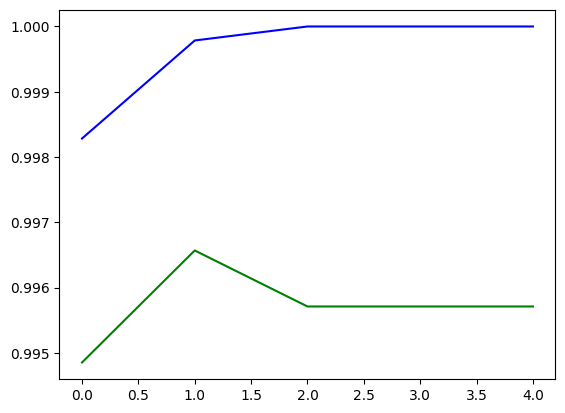

In [ ]:
plt.plot(his.history["accuracy"] , color="blue")
plt.plot(his.history["val_accuracy"] , color="green")
plt.show()

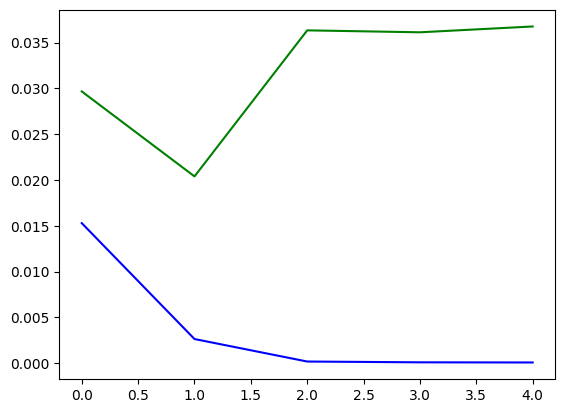

In [ ]:
plt.plot(his.history["loss"] , color="blue")
plt.plot(his.history["val_loss"] , color="green")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score , recall_score , confusion_matrix , precision_score
pred = model.predict(X_test)
pred_train = model.predict(X_train)

a = accuracy_score(Y_test , pred.round())
at = accuracy_score(Y_train , pred_train.round())
r = recall_score(Y_test , pred.round())
c = confusion_matrix(Y_test , pred.round())
p = precision_score(Y_test , pred.round())
a ,at, c , p , r

37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step
146/146 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step


(0.9965694682675815,
 1.0,
 array([[562,   3],
        [  1, 600]]),
 0.9950248756218906,
 0.9983361064891847)

In [ ]:
import pickle

with open("model.pkl" ,"wb") as f:
    pickle.dump(model, f)

with open("Tokenzier.pkl" ,"wb") as f:
    pickle.dump(token, f)